In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from sklearn import tree

In [2]:
# Load dataset
df = pd.read_csv("Sony(PSP).csv")

# Preview dataset
df.head()

,Name,Studio,UPC,Price,ESRB,Platform,Released_on,Dimensions,Weight,Cover_image
0,Wall.E (PSP) by THQ,THQ,4005209106320,55.13,Rating Pending,Sony PSP,8/18/2042,4.0900 x 0.5500,0.2200 lbs.,https://secure.coverart.bookstores.com/large/6...
1,NASCAR 07 (PSP),Electronic Arts,5030930051440,19.99,Unknown,Sony PSP,10/5/2006,4.0900 x 0.6300,0.1800 lbs.,https://secure.coverart.bookstores.com/large/0...
2,Battle Over The Pacific (PSP),Midas,5036675013415,14.99,Unknown,Sony PSP,3/21/2008,4.0900 x 0.4700,0.1800 lbs.,https://secure.coverart.bookstores.com/large/0...
3,Prince of Persia: Revelations - Sony PSP,"""Sega of America, Inc.""",8888331988,19.99,Mature,Sony PSP,9/8/2006,4.1000 x 0.6000,0.2000 lbs.,https://secure.coverart.bookstores.com/large/5...
4,Assassin's Creed: Bloodlines - Sony PSP,UBI Soft,8888335733,19.99,Mature,Sony PSP,11/17/2009,4.1000 x 0.6000,0.1000 lbs.,https://secure.coverart.bookstores.com/large/0...


In [3]:
# Dataset info
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         53 non-null     str    
 1   Studio       53 non-null     str    
 2   UPC          53 non-null     int64  
 3   Price        53 non-null     float64
 4   ESRB         53 non-null     str    
 5   Platform     53 non-null     str    
 6   Released_on  53 non-null     str    
 7   Dimensions   53 non-null     str    
 8   Weight       53 non-null     str    
 9   Cover_image  53 non-null     str    
dtypes: float64(1), int64(1), str(8)
memory usage: 12.4 KB


Name           0
Studio         0
UPC            0
Price          0
ESRB           0
Platform       0
Released_on    0
Dimensions     0
Weight         0
Cover_image    0
dtype: int64

In [4]:
# Drop rows with missing values
df = df.dropna()

# Convert categorical columns to numeric if needed
df = pd.get_dummies(df, drop_first=True)

df.head()

,UPC,Price,Name_ Assassin's Creed: Bloodlines - Sony PSP,Name_ Battle Over The Pacific (PSP),Name_ Dead Or Alive Paradise,Name_ Dragon Ball Z: Tenkaichi Tag Team - Essentials (PSP),Name_ Dragonball Z Shin Budokai - Sony PSP,Name_ FIFA 13 (Sony PSP),Name_ Final Fantasy IV - The Complete Collection (PSP) by Square Enix,Name_ Formula 1 2009 (PSP),Name_ God of War: Ghost of Sparta - Sony PSP,Name_ Grand Theft Auto: Chinatown Wars - Sony PSP,Name_ Harvest Moon: Hero of Leaf Valley - Sony PSP,Name_ Invizimals Shadow Zone : Game plus PSP Camera,Name_ Kingdom Hearts: Birth by Sleep - Sony PSP,Name_ LEGO Indiana Jones 2 The Adventure Continues (Sony PSP) (UK Import),Name_ LEGO Star Wars 3: The Clone Wars (PSP),Name_ LEGO Star Wars III The Clone Wars - Sony PSP,Name_ Lego Batman: The Videogame - Platinum Edition (PSP),Name_ Lego Star Wars II: The Original Trilogy - Sony PSP,Name_ Lemmings - Platinum Edition (PSP),Name_ Lunar: Silver Star Harmony - Sony PSP,Name_ Madden NFL 11 - Sony PSP,Name_ Madden NFL 12 - Sony PSP,Name_ Major League Baseball 2K11,Name_ Metal Gear Acid,Name_ Metal Gear Solid Digital Graphic Novel (PSP),Name_ Metal Gear Solid Peace Walker,Name_ Metal Slug Anthology (PSP),Name_ Metal Slug XX,Name_ Michael Jackson The Experience - Sony PSP,Name_ Military History Commander: Europe at War (PSP) by Slitherine,Name_ NASCAR 07 (PSP),Name_ NCAA Football 10 - Sony PSP,Name_ Namco Museum Battle Collection,Name_ Naruto Shippuden: Ultimate Ninja Impact (PSP),Name_ Naruto: Ultimate Ninja Heroes 2 (PSP),Name_ Naruto: Ultimate Ninja Heroes 2: The Phantom Fortress - Sony PSP,Name_ Need for Speed Most Wanted - Sony PSP,Name_ Prince of Persia: Revelations - Sony PSP,...,Cover_image_https://secure.coverart.bookstores.com/large/095/3-131095.jpg,Cover_image_https://secure.coverart.bookstores.com/large/126/3-30126.jpg,Cover_image_https://secure.coverart.bookstores.com/large/211/3-39211.jpg,Cover_image_https://secure.coverart.bookstores.com/large/216/3-9216.jpg,Cover_image_https://secure.coverart.bookstores.com/large/218/3-128218.jpg,Cover_image_https://secure.coverart.bookstores.com/large/220/3-30220.jpg,Cover_image_https://secure.coverart.bookstores.com/large/264/3-138264.jpg,Cover_image_https://secure.coverart.bookstores.com/large/290/3-81290.jpg,Cover_image_https://secure.coverart.bookstores.com/large/307/3-39307.jpg,Cover_image_https://secure.coverart.bookstores.com/large/313/3-63313.jpg,Cover_image_https://secure.coverart.bookstores.com/large/367/3-128367.jpg,Cover_image_https://secure.coverart.bookstores.com/large/368/3-128368.jpg,Cover_image_https://secure.coverart.bookstores.com/large/381/3-65381.jpg,Cover_image_https://secure.coverart.bookstores.com/large/428/3-152428.jpg,Cover_image_https://secure.coverart.bookstores.com/large/441/3-30441.jpg,Cover_image_https://secure.coverart.bookstores.com/large/499/3-58499.jpg,Cover_image_https://secure.coverart.bookstores.com/large/550/3-5550.jpg,Cover_image_https://secure.coverart.bookstores.com/large/579/3-63579.jpg,Cover_image_https://secure.coverart.bookstores.com/large/592/3-72592.jpg,Cover_image_https://secure.coverart.bookstores.com/large/605/3-56605.jpg,Cover_image_https://secure.coverart.bookstores.com/large/612/3-64612.jpg,Cover_image_https://secure.coverart.bookstores.com/large/624/3-5624.jpg,Cover_image_https://secure.coverart.bookstores.com/large/626/3-83626.jpg,Cover_image_https://secure.coverart.bookstores.com/large/639/3-63639.jpg,Cover_image_https://secure.coverart.bookstores.com/large/641/3-69641.jpg,Cover_image_https://secure.coverart.bookstores.com/large/657/3-5657.jpg,Cover_image_https://secure.coverart.bookstores.com/large/671/3-56671.jpg,Cover_image_https://secure.coverart.bookstores.com/large/697/3-5697.jpg,Cover_image_https://secure.coverart.bookstores.com/large/733/3-5733.jpg,Cover_image_https://secure.coverart.bookstores.com/large/754/3-5754.jpg,Cover_image_https://secure.coverart.bookstores.com/large/779/3-64779.jpg,Cover_image_https://secure.coverart.bookstores.co

In [6]:
print(df.columns)

Index(['UPC', 'Price', 'Name_ Assassin's Creed: Bloodlines - Sony PSP',
       'Name_ Battle Over The Pacific (PSP)', 'Name_ Dead Or Alive Paradise',
       'Name_ Dragon Ball Z: Tenkaichi Tag Team - Essentials (PSP)',
       'Name_ Dragonball Z Shin Budokai - Sony PSP',
       'Name_ FIFA 13 (Sony PSP)',
       'Name_ Final Fantasy IV - The Complete Collection (PSP) by Square Enix',
       'Name_ Formula 1 2009 (PSP)',
       ...
       'Cover_image_https://secure.coverart.bookstores.com/large/779/3-64779.jpg',
       'Cover_image_https://secure.coverart.bookstores.com/large/791/3-82791.jpg',
       'Cover_image_https://secure.coverart.bookstores.com/large/820/3-5820.jpg',
       'Cover_image_https://secure.coverart.bookstores.com/large/824/3-63824.jpg',
       'Cover_image_https://secure.coverart.bookstores.com/large/902/3-5902.jpg',
       'Cover_image_https://secure.coverart.bookstores.com/large/929/3-30929.jpg',
       'Cover_image_https://secure.coverart.bookstores.com/large/956/

In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# Predictions
dt_predictions = dt_model.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))

print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_predictions))

Decision Tree Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [13]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

Random Forest Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


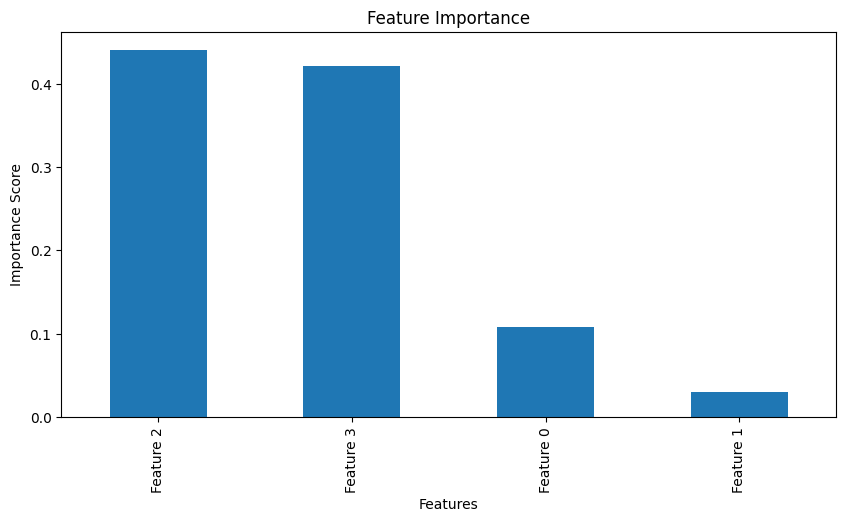

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance values from the trained Random Forest model
importances = rf_model.feature_importances_

# Create feature names automatically based on number of columns in X
feature_names = [f"Feature {i}" for i in range(X.shape[1])]

# Create a pandas Series for easier plotting
feature_importance = pd.Series(importances, index=feature_names)

# Sort and plot the feature importance
feature_importance.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10,5),
    title="Feature Importance"
)

plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.show()